In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -q transformers datasets mlflow torch scikit-learn pandas numpy seaborn matplotlib

print("Installation complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installation complete!


In [ ]:
import mlflow
import os

# Set MLflow to local tracking (in Colab)
mlflow.set_tracking_uri("file:///content/mlruns")

# Create mlruns directory
os.makedirs("/content/mlruns", exist_ok=True)

print("MLflow tracking set to local Colab storage")
print("Tracking URI:", mlflow.get_tracking_uri())

# Test
client = mlflow.tracking.MlflowClient()
print("MLflow client initialized!")

MLflow tracking set to local Colab storage
Tracking URI: file:///content/mlruns
MLflow client initialized!


In [ ]:
import pandas as pd
import json

# Load datasets from Google Drive
DATA_PATH = "/content/drive/MyDrive/mental-health-mlops/data"

print("Loading data...")
train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
val_df = pd.read_csv(f"{DATA_PATH}/val.csv")
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Load class weights
with open("/content/drive/MyDrive/mental-health-mlops/class_weights.json", 'r') as f:
    class_weights = json.load(f)

print(f"\nClass weights loaded:")
for class_name, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"   {class_name:20s}: {weight:.3f}")

# Display sample
print("\n📋 Sample data:")
print(train_df.head(3))

Loading data...
Train: 36119 samples
Val: 7740 samples
Test: 7740 samples

Class weights loaded:
   Stress              : 3.324
   Bipolar             : 3.097
   Anxiety             : 2.239
   Suicidal            : 0.807
   Depression          : 0.558
   Normal              : 0.526

📋 Sample data:
                                                text       label
0  health anxiety when sick hi everyone, ive had ...     Anxiety
1     zerohedge depression is spelled with a d not r  Depression
2  okay so, since i was young, i love coffee. i h...  Depression


In [ ]:
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset
import numpy as np

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['label'])
val_labels = label_encoder.transform(val_df['label'])
test_labels = label_encoder.transform(test_df['label'])

# Create label mappings
label_to_id = {label: idx for idx, label in enumerate(label_encoder.classes_)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print("Label mapping:")
for label, idx in label_to_id.items():
    count = (train_df['label'] == label).sum()
    print(f"   {idx}: {label:20s} ({count:5d} samples)")

# Convert class weights to tensor
class_weight_list = [class_weights[label] for label in label_encoder.classes_]
class_weight_tensor = torch.tensor(class_weight_list, dtype=torch.float32)

print(f"\nClass weights tensor shape: {class_weight_tensor.shape}")

# Custom Dataset class
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Dataset class defined!")

Label mapping:
   0: Anxiety              ( 2689 samples)
   1: Bipolar              ( 1944 samples)
   2: Depression           (10783 samples)
   3: Normal               (11437 samples)
   4: Stress               ( 1811 samples)
   5: Suicidal             ( 7455 samples)

Class weights tensor shape: torch.Size([6])
Dataset class defined!


In [ ]:
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

def compute_metrics(pred):
    """Compute metrics for evaluation"""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }


def train_distilbert(
    train_df,
    val_df,
    learning_rate=2e-5,
    batch_size=16,
    epochs=5,
    use_class_weights=True,
    max_length=128,
    experiment_name="transformer-distilbert",
    run_name=None
):
    """
    Train DistilBERT model and log to MLflow
    """

    # Set experiment
    mlflow.set_experiment(experiment_name)

    # Start MLflow run
    if run_name is None:
        run_name = f"distilbert_lr{learning_rate}_bs{batch_size}_cw{use_class_weights}"

    with mlflow.start_run(run_name=run_name):

        print(f"\n{'='*70}")
        print(f" TRAINING: {run_name}")
        print(f"{'='*70}")

        start_time = time.time()

        # Log parameters
        mlflow.log_param("model_type", "distilbert-base-uncased")
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("max_epochs", epochs)
        mlflow.log_param("max_length", max_length)
        mlflow.log_param("use_class_weights", use_class_weights)
        mlflow.log_param("train_samples", len(train_df))
        mlflow.log_param("val_samples", len(val_df))

        # Initialize tokenizer
        print("\n Loading tokenizer...")
        tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

        # Create datasets
        print(" Creating datasets...")
        train_dataset = MentalHealthDataset(
            train_df['text'].values,
            train_labels,
            tokenizer,
            max_length=max_length
        )

        val_dataset = MentalHealthDataset(
            val_df['text'].values,
            val_labels,
            tokenizer,
            max_length=max_length
        )

        print(f"   Train dataset: {len(train_dataset)} samples")
        print(f"   Val dataset: {len(val_dataset)} samples")

        # Initialize model
        print("\n Loading DistilBERT model...")
        num_labels = len(label_encoder.classes_)
        model = DistilBertForSequenceClassification.from_pretrained(
            'distilbert-base-uncased',
            num_labels=num_labels
        )

        # Move to GPU
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        if use_class_weights:
            class_weight_tensor_device = class_weight_tensor.to(device)

        print(f" Using device: {device}")
        mlflow.log_param("device", str(device))

        # Training arguments
        training_args = TrainingArguments(
            output_dir='/content/results',
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            warmup_steps=500,
            weight_decay=0.01,
            logging_dir='/content/logs',
            logging_steps=100,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            learning_rate=learning_rate,
            save_total_limit=2,
            report_to="none",
            fp16=torch.cuda.is_available()  # Use mixed precision on GPU
        )

        # Custom Trainer with class weights - FIXED VERSION
        class WeightedTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                # Accept **kwargs to handle any additional arguments
                labels = inputs.pop("labels")
                outputs = model(**inputs)
                logits = outputs.logits

                if use_class_weights:
                    loss_fct = torch.nn.CrossEntropyLoss(weight=class_weight_tensor_device)
                else:
                    loss_fct = torch.nn.CrossEntropyLoss()

                loss = loss_fct(logits, labels)
                return (loss, outputs) if return_outputs else loss

        # Initialize trainer
        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )

        # Train
        print(f"\n{'='*70}")
        print(" TRAINING STARTED...")
        print(f"{'='*70}")
        train_result = trainer.train()

        training_time = time.time() - start_time
        mlflow.log_metric("training_time_minutes", training_time / 60)

        print(f"\n Training completed in {training_time/60:.1f} minutes")

        # Final evaluation
        print(f"\n{'='*70}")
        print(" FINAL EVALUATION")
        print(f"{'='*70}")
        eval_result = trainer.evaluate()

        # Log metrics
        for key, value in eval_result.items():
            if key.startswith('eval_'):
                metric_name = key.replace('eval_', 'val_')
                mlflow.log_metric(metric_name, value)

        print(f"\n🎯 Validation Results:")
        print(f"   Accuracy:  {eval_result['eval_accuracy']:.4f}")
        print(f"   F1 Macro:  {eval_result['eval_f1_macro']:.4f}")
        print(f"   Precision: {eval_result['eval_precision_macro']:.4f}")
        print(f"   Recall:    {eval_result['eval_recall_macro']:.4f}")

        # Get predictions for per-class metrics
        print("\n Computing per-class metrics...")
        predictions = trainer.predict(val_dataset)
        y_pred = predictions.predictions.argmax(-1)
        y_true = val_labels

        # Classification report
        report = classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            output_dict=True,
            zero_division=0
        )

        # Log and display per-class metrics
        print(f"\n Per-Class Performance:")
        print(f"{'Class':<20} {'F1':>6} {'Precision':>10} {'Recall':>8}")
        print(f"{'-'*50}")

        for class_name in label_encoder.classes_:
            if class_name in report:
                f1 = report[class_name]['f1-score']
                precision = report[class_name]['precision']
                recall = report[class_name]['recall']

                print(f"{class_name:<20} {f1:>6.3f} {precision:>10.3f} {recall:>8.3f}")

                mlflow.log_metric(f"val_f1_{class_name}", f1)
                mlflow.log_metric(f"val_precision_{class_name}", precision)
                mlflow.log_metric(f"val_recall_{class_name}", recall)

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_)
        plt.title(f'Confusion Matrix: {run_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()

        cm_path = '/content/confusion_matrix.png'
        plt.savefig(cm_path)
        plt.show()

        mlflow.log_artifact(cm_path)

        # Save model
        print("\n Saving model...")
        model_path = "/content/distilbert_model"
        trainer.save_model(model_path)
        tokenizer.save_pretrained(model_path)

        print(f"\n{'='*70}")
        print(f" EXPERIMENT COMPLETE!")
        print(f"{'='*70}")
        print(f" MLflow Run ID: {mlflow.active_run().info.run_id}")
        print(f" Total Time: {training_time/60:.1f} minutes")
        print(f" Final F1 Score: {eval_result['eval_f1_macro']:.4f}")
        print(f"{'='*70}\n")

        return eval_result['eval_f1_macro'], eval_result

print("Training function defined!")

Training function defined!


EXPERIMENT 1: Baseline DistilBERT (No Class Weights)

 TRAINING: distilbert_baseline_no_weights

 Loading tokenizer...
 Creating datasets...
   Train dataset: 36119 samples
   Val dataset: 7740 samples

 Loading DistilBERT model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Using device: cuda

 TRAINING STARTED...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.486900,0.477850,0.801550,0.779953,0.794003,0.778574
2,0.400700,0.447724,0.818992,0.805255,0.808865,0.804125
3,0.264800,0.496057,0.816796,0.808794,0.809059,0.815480


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.486900,0.477850,0.801550,0.779953,0.794003,0.778574
2,0.400700,0.447724,0.818992,0.805255,0.808865,0.804125
3,0.264800,0.496057,0.816796,0.808794,0.809059,0.815480
4,0.198700,0.572233,0.818346,0.806895,0.802315,0.814187
5,0.156800,0.649501,0.820284,0.810414,0.809414,0.812147



✅ Training completed in 20.2 minutes

 FINAL EVALUATION



🎯 Validation Results:
   Accuracy:  0.8203
   F1 Macro:  0.8104
   Precision: 0.8094
   Recall:    0.8121

 Computing per-class metrics...

 Per-Class Performance:
Class                    F1  Precision   Recall
--------------------------------------------------
Anxiety               0.868      0.869    0.866
Bipolar               0.850      0.871    0.829
Depression            0.765      0.766    0.765
Normal                0.952      0.948    0.956
Stress                0.735      0.702    0.771
Suicidal              0.693      0.700    0.686


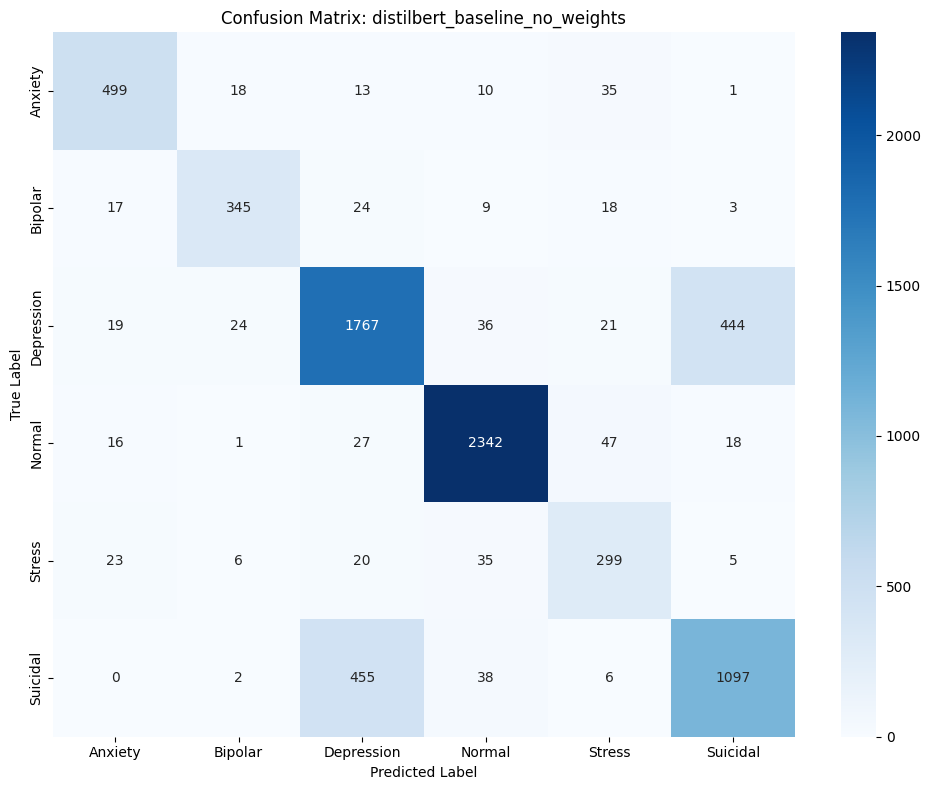


💾 Saving model...

 EXPERIMENT COMPLETE!
📊 MLflow Run ID: d48a7f364c774ab3894e8a844e444c45
⏱️  Total Time: 20.2 minutes
🎯 Final F1 Score: 0.8104


 Experiment 1 Complete!
   F1 Macro: 0.8104
   Baseline (LightGBM): 0.771
   Improvement: +3.9%


In [13]:
print("="*70)
print("EXPERIMENT 1: Baseline DistilBERT (No Class Weights)")
print("="*70)

f1_score, results = train_distilbert(
    train_df=train_df,
    val_df=val_df,
    learning_rate=2e-5,
    batch_size=16,
    epochs=5,
    use_class_weights=False,
    run_name="distilbert_baseline_no_weights"
)

print(f"\n Experiment 1 Complete!")
print(f"   F1 Macro: {f1_score:.4f}")
print(f"   Baseline (LightGBM): 0.771")
print(f"   Improvement: {(f1_score - 0.771)*100:+.1f}%")

EXPERIMENT 2: DistilBERT WITH Class Weights

 TRAINING: distilbert_with_class_weights

 Loading tokenizer...
 Creating datasets...
   Train dataset: 36119 samples
   Val dataset: 7740 samples

 Loading DistilBERT model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Using device: cuda

 TRAINING STARTED...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.590500,0.522329,0.789147,0.780548,0.777884,0.809433
2,0.447000,0.485963,0.812661,0.804309,0.794628,0.823435
3,0.271000,0.550442,0.803101,0.803489,0.804145,0.824977
4,0.212600,0.595496,0.822610,0.817285,0.811139,0.826409
5,0.163900,0.643063,0.822868,0.818851,0.813438,0.826720



✅ Training completed in 21.4 minutes

 FINAL EVALUATION



🎯 Validation Results:
   Accuracy:  0.8229
   F1 Macro:  0.8189
   Precision: 0.8134
   Recall:    0.8267

 Computing per-class metrics...

 Per-Class Performance:
Class                    F1  Precision   Recall
--------------------------------------------------
Anxiety               0.881      0.879    0.884
Bipolar               0.859      0.877    0.841
Depression            0.759      0.791    0.730
Normal                0.949      0.951    0.947
Stress                0.754      0.700    0.817
Suicidal              0.710      0.682    0.741


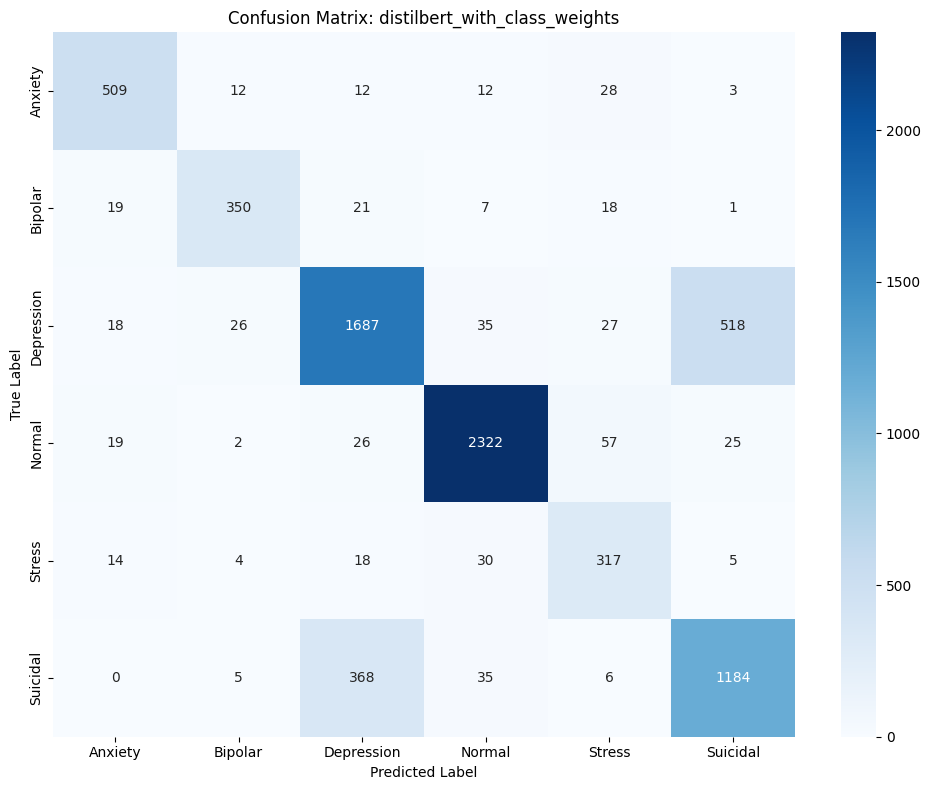


💾 Saving model...

 EXPERIMENT COMPLETE!
📊 MLflow Run ID: 87db12077f704fb2ab288852bf68cf51
⏱️  Total Time: 21.4 minutes
🎯 Final F1 Score: 0.8189


 Experiment 2 Complete!
   F1 Macro: 0.8189
   Baseline (LightGBM): 0.771
   Improvement: +4.8%


In [14]:
print("="*70)
print("EXPERIMENT 2: DistilBERT WITH Class Weights")
print("="*70)

f1_score_2, results_2 = train_distilbert(
    train_df=train_df,
    val_df=val_df,
    learning_rate=2e-5,
    batch_size=16,
    epochs=5,
    use_class_weights=True,  # KEY DIFFERENCE!
    run_name="distilbert_with_class_weights"
)

print(f"\n Experiment 2 Complete!")
print(f"   F1 Macro: {f1_score_2:.4f}")
print(f"   Baseline (LightGBM): 0.771")
print(f"   Improvement: {(f1_score_2 - 0.771)*100:+.1f}%")

EXPERIMENT 3: Higher Learning Rate (5e-5)

 TRAINING: distilbert_lr5e5_class_weights

 Loading tokenizer...
 Creating datasets...
   Train dataset: 36119 samples
   Val dataset: 7740 samples

 Loading DistilBERT model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Using device: cuda

 TRAINING STARTED...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.584900,0.530745,0.790439,0.777494,0.768755,0.805011
2,0.452200,0.495909,0.805685,0.798461,0.791558,0.820433
3,0.240200,0.574529,0.809948,0.809465,0.803723,0.828472
4,0.166600,0.738403,0.816796,0.813402,0.808689,0.820749
5,0.098600,0.870604,0.818346,0.815288,0.813300,0.817925



✅ Training completed in 20.5 minutes

 FINAL EVALUATION



🎯 Validation Results:
   Accuracy:  0.8183
   F1 Macro:  0.8153
   Precision: 0.8133
   Recall:    0.8179

 Computing per-class metrics...

 Per-Class Performance:
Class                    F1  Precision   Recall
--------------------------------------------------
Anxiety               0.887      0.891    0.882
Bipolar               0.855      0.868    0.841
Depression            0.757      0.770    0.745
Normal                0.947      0.940    0.954
Stress                0.757      0.726    0.791
Suicidal              0.689      0.684    0.694


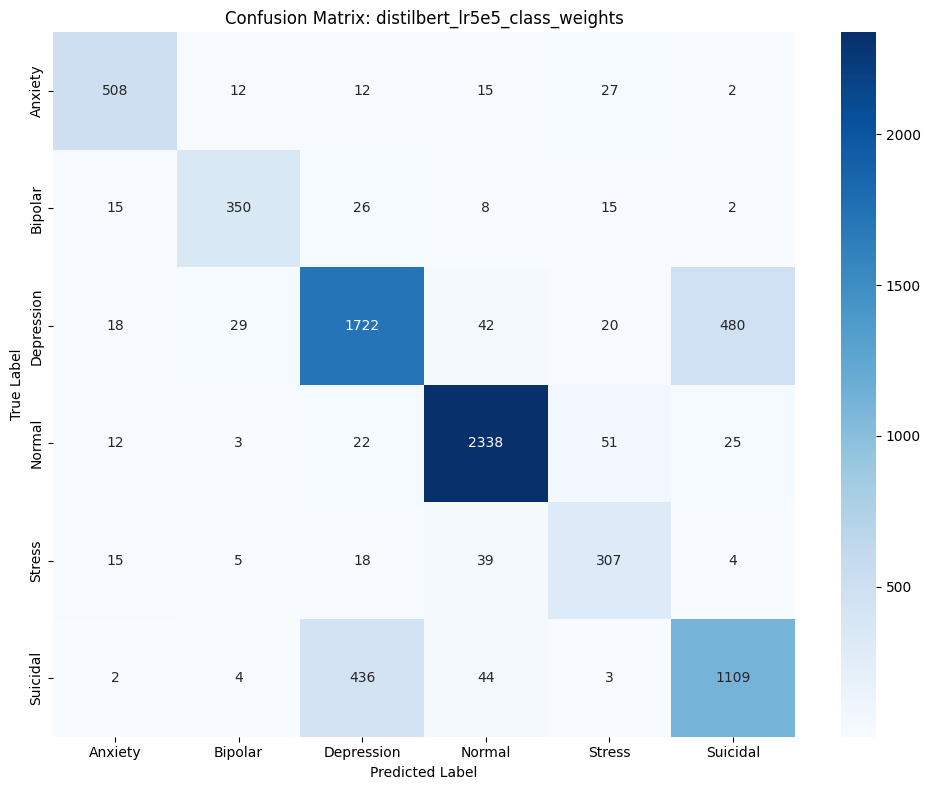


💾 Saving model...

 EXPERIMENT COMPLETE!
📊 MLflow Run ID: 8d4b3fb81bed48be9a13e1685a3d1a37
⏱️  Total Time: 20.5 minutes
🎯 Final F1 Score: 0.8153


Experiment 3 Complete!
   F1 Macro: 0.8153


In [15]:
print("="*70)
print("EXPERIMENT 3: Higher Learning Rate (5e-5)")
print("="*70)

f1_score_3, results_3 = train_distilbert(
    train_df=train_df,
    val_df=val_df,
    learning_rate=5e-5,  # Higher LR
    batch_size=16,
    epochs=5,
    use_class_weights=True,
    run_name="distilbert_lr5e5_class_weights"
)

print(f"\nExperiment 3 Complete!")
print(f"   F1 Macro: {f1_score_3:.4f}")

EXPERIMENT 4: Lower Learning Rate (1e-5)

 TRAINING: distilbert_lr1e5_class_weights

 Loading tokenizer...
 Creating datasets...
   Train dataset: 36119 samples
   Val dataset: 7740 samples

 Loading DistilBERT model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Using device: cuda

 TRAINING STARTED...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.616400,0.535028,0.778295,0.763180,0.754671,0.804678
2,0.479900,0.505898,0.808786,0.798818,0.790433,0.822075
3,0.345800,0.518668,0.806718,0.801451,0.793568,0.826407
4,0.318700,0.534174,0.820155,0.810335,0.797549,0.829581
5,0.265800,0.545167,0.821576,0.815200,0.806283,0.830383



✅ Training completed in 21.3 minutes

 FINAL EVALUATION



🎯 Validation Results:
   Accuracy:  0.8216
   F1 Macro:  0.8152
   Precision: 0.8063
   Recall:    0.8304

 Computing per-class metrics...

 Per-Class Performance:
Class                    F1  Precision   Recall
--------------------------------------------------
Anxiety               0.876      0.870    0.882
Bipolar               0.852      0.870    0.834
Depression            0.757      0.810    0.710
Normal                0.947      0.954    0.940
Stress                0.739      0.656    0.845
Suicidal              0.721      0.677    0.772


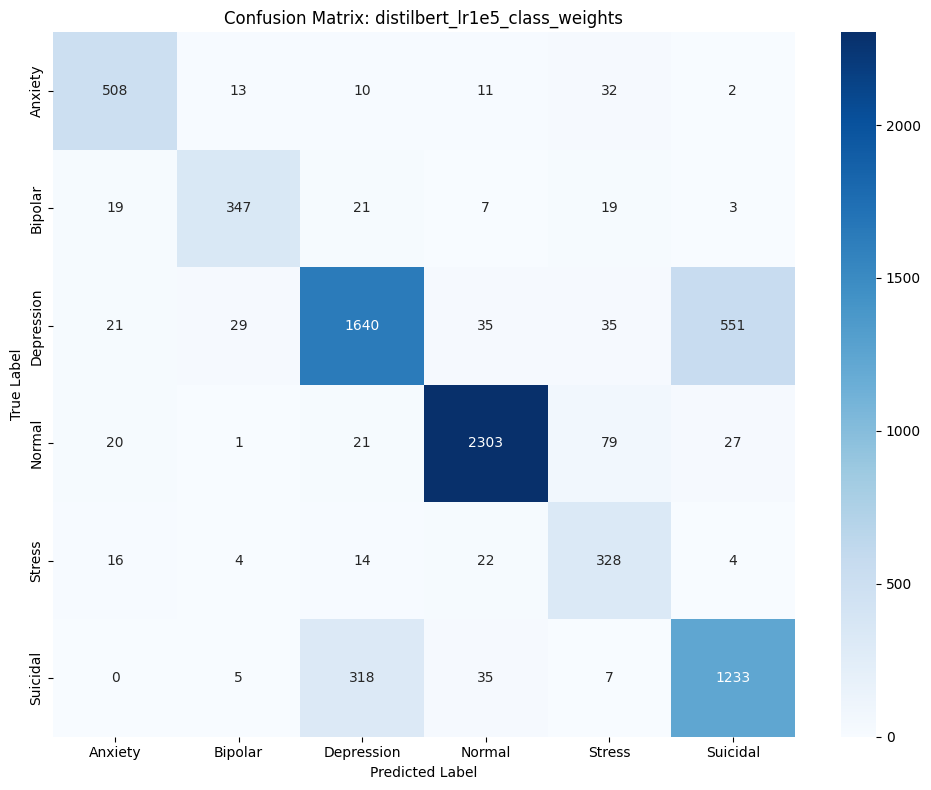


💾 Saving model...

 EXPERIMENT COMPLETE!
📊 MLflow Run ID: b1c7ef0444e0475fbf77ec609edb571d
⏱️  Total Time: 21.3 minutes
🎯 Final F1 Score: 0.8152


Experiment 4 Complete!
   F1 Macro: 0.8152


In [16]:
print("="*70)
print("EXPERIMENT 4: Lower Learning Rate (1e-5)")
print("="*70)

f1_score_4, results_4 = train_distilbert(
    train_df=train_df,
    val_df=val_df,
    learning_rate=1e-5,  # Lower LR
    batch_size=16,
    epochs=5,
    use_class_weights=True,
    run_name="distilbert_lr1e5_class_weights"
)

print(f"\nExperiment 4 Complete!")
print(f"   F1 Macro: {f1_score_4:.4f}")

In [17]:
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)

experiments_summary = [
    ("Baseline (LightGBM + SMOTE)", 0.771, 0.699),  # From earlier
    ("Exp 1: DistilBERT (no weights)", f1_score, None),  # Replace with actual
    ("Exp 2: DistilBERT (class weights)", f1_score_2, None),
    ("Exp 3: DistilBERT (LR=5e-5)", f1_score_3, None),
    ("Exp 4: DistilBERT (LR=1e-5)", f1_score_4, None),
]

print(f"\n{'Experiment':<40} {'F1 Macro':>10} {'vs Baseline':>12}")
print("-"*70)

for exp_name, f1, suicidal_f1 in experiments_summary:
    improvement = (f1 - 0.771) * 100
    print(f"{exp_name:<40} {f1:>10.4f} {improvement:>11.1f}%")

print("="*70)
print(f"\n Best Model: {max(experiments_summary, key=lambda x: x[1])[0]}")
print(f" Best F1 Score: {max(experiments_summary, key=lambda x: x[1])[1]:.4f}")
print("="*70)


EXPERIMENT SUMMARY

Experiment                                 F1 Macro  vs Baseline
----------------------------------------------------------------------
Baseline (LightGBM + SMOTE)                  0.7710         0.0%
Exp 1: DistilBERT (no weights)               0.8104         3.9%
Exp 2: DistilBERT (class weights)            0.8189         4.8%
Exp 3: DistilBERT (LR=5e-5)                  0.8153         4.4%
Exp 4: DistilBERT (LR=1e-5)                  0.8152         4.4%

 Best Model: Exp 2: DistilBERT (class weights)
 Best F1 Score: 0.8189


**FOR COLAB ONLY**

In [18]:
# Cell 11: Package MLflow experiments for download
import shutil

print("Packaging MLflow experiments...")

# Zip the mlruns folder
shutil.make_archive('/content/mlruns', 'zip', '/content/mlruns')

print("MLflow experiments packaged!")
print("Download the file: mlruns.zip")
print("\n Location: /content/mlruns.zip")
print("\nTo download: Click on folder icon (left sidebar) → Right-click mlruns.zip → Download")

Packaging MLflow experiments...
MLflow experiments packaged!
Download the file: mlruns.zip

 Location: /content/mlruns.zip

To download: Click on folder icon (left sidebar) → Right-click mlruns.zip → Download
